# 05b — Series Model Explainability (SHAP)

Apply SHAP to the best series model (XGBoost) to understand which features drive predictions.

**Input:** `data/processed/series_features.parquet`, `models/series_xgboost.joblib`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

sys.path.insert(0, str(Path().resolve().parent))
from src.models import load_model, train_test_split_by_season

/Users/mearly/dev/playground/Sports/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROCESSED_DIR = Path().resolve().parent / "data" / "processed"
TEST_SEASONS = ["2022-23", "2023-24"]
TARGET_COL = "higher_seed_wins"

FEATURE_COLS = [
    "home_ortg", "away_ortg", "home_drtg", "away_drtg",
    "home_net_rtg", "away_net_rtg", "net_rtg_diff",
    "home_pace", "away_pace", "ortg_diff", "drtg_diff",
    "home_win_pct", "away_win_pct", "win_pct_diff",
    "home_oreb_pct", "away_oreb_pct",
    "home_tov_pct", "away_tov_pct",
    "home_playoff_win_pct_3yr", "away_playoff_win_pct_3yr", "playoff_win_pct_diff",
    "home_finals_apps_5yr", "away_finals_apps_5yr",
]

## 1. Load Data + Model

In [3]:
df = pd.read_parquet(PROCESSED_DIR / "series_features.parquet")
train_df, test_df = train_test_split_by_season(df, TEST_SEASONS)

X_train = train_df[FEATURE_COLS]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

pipeline = load_model("series_xgboost")
scaler = pipeline.named_steps["scaler"]
clf    = pipeline.named_steps["clf"]

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=FEATURE_COLS)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=FEATURE_COLS)

print(f"Train: {len(X_train)} | Test: {len(X_test)} series")

Train: 105 | Test: 30 series


## 2. Compute SHAP Values

In [4]:
explainer   = shap.TreeExplainer(clf)
shap_train  = explainer.shap_values(X_train_scaled)
shap_test   = explainer.shap_values(X_test_scaled)

print(f"SHAP values shape (test): {np.array(shap_test).shape}")
print(f"Expected value (base rate): {explainer.expected_value:.3f}")

SHAP values shape (test): (30, 23)
Expected value (base rate): 1.159


## 3. Global Feature Importance — Bar Chart (Training Set)

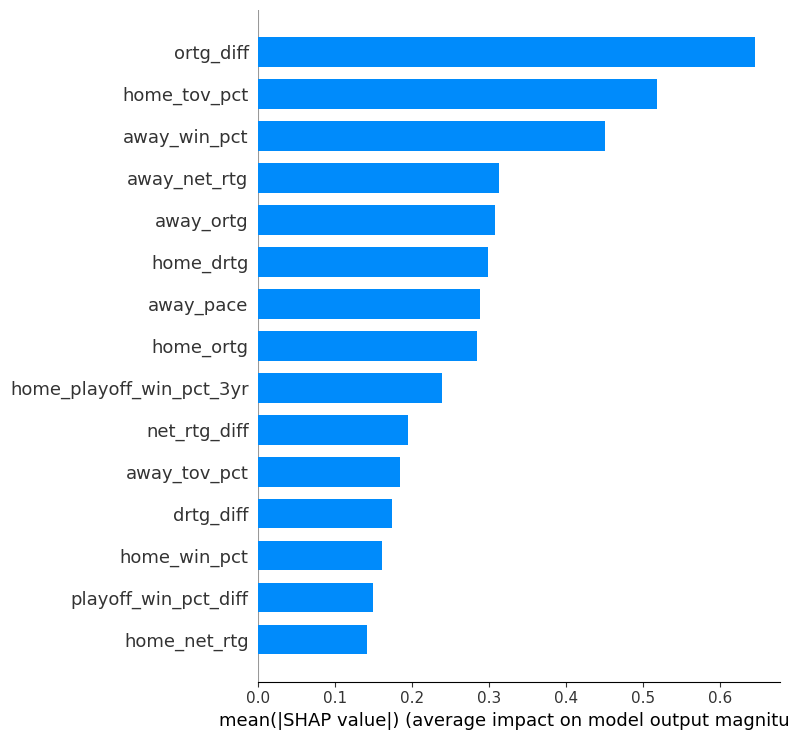

In [5]:
shap.summary_plot(
    shap_train,
    X_train_scaled,
    plot_type="bar",
    max_display=15,
    show=True,
)

## 4. Beeswarm — Direction + Magnitude of Each Feature

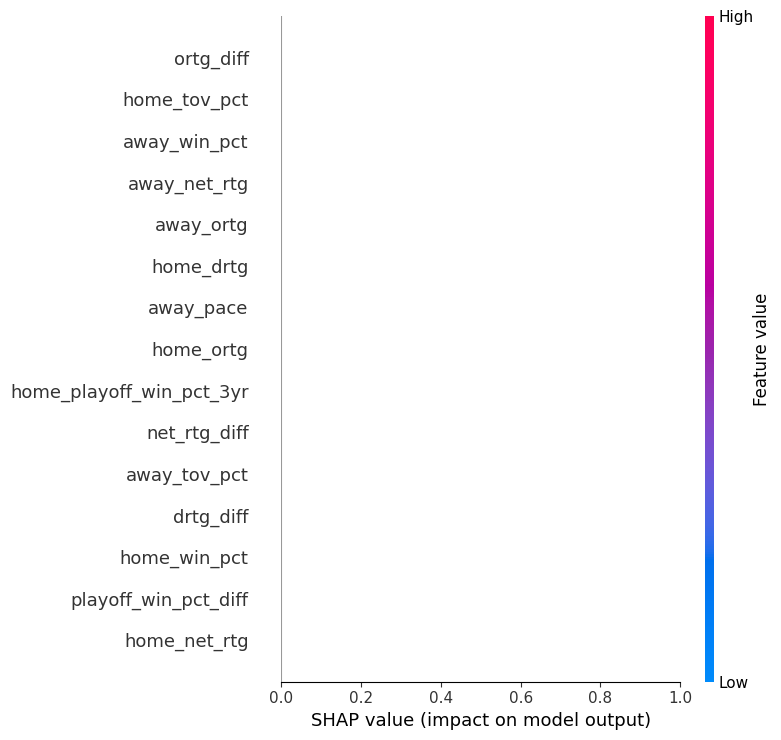

In [6]:
shap.summary_plot(
    shap_train,
    X_train_scaled,
    plot_type="beeswarm",
    max_display=15,
    show=True,
)

## 5. Top Feature Table

In [7]:
mean_abs_shap = pd.Series(
    np.abs(shap_train).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)

print("Top 10 features by mean |SHAP|:")
print(mean_abs_shap.head(10).round(4).to_string())

Top 10 features by mean |SHAP|:
ortg_diff                   0.6451
home_tov_pct                0.5171
away_win_pct                0.4501
away_net_rtg                0.3130
away_ortg                   0.3069
home_drtg                   0.2987
away_pace                   0.2878
home_ortg                   0.2836
home_playoff_win_pct_3yr    0.2387
net_rtg_diff                0.1943


## 6. Example Prediction — Waterfall for a Correctly Called Upset

No correctly-called upsets in holdout — showing first test series instead


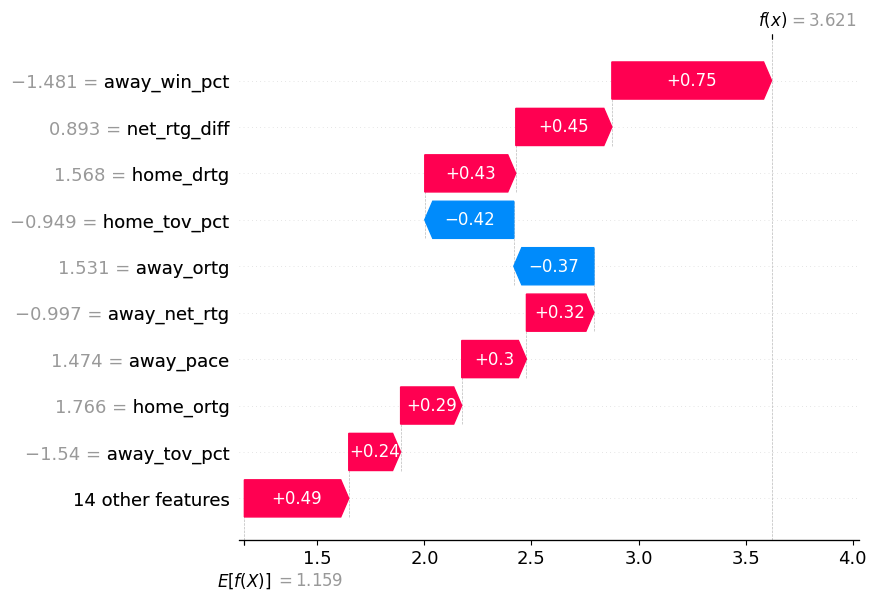

In [8]:
# Find a series the model got right where the lower seed won
preds = pipeline.predict(X_test)
probs = pipeline.predict_proba(X_test)[:, 1]
test_results = test_df.copy()
test_results["predicted"] = preds
test_results["prob_higher_seed"] = probs
test_results["correct"] = (preds == y_test.values).astype(int)

# Upsets correctly called: lower seed won AND model predicted lower seed
correct_upsets = test_results[
    (test_results[TARGET_COL] == 0) & (test_results["predicted"] == 0)
]

if len(correct_upsets) > 0:
    idx = correct_upsets.index[0]
    pos = test_df.index.get_loc(idx)
    print(f"Series: {test_results.loc[idx, 'series_key']}")
    print(f"Predicted: lower seed wins | Actual: lower seed won ✓")
    print(f"Model prob (higher seed wins): {probs[pos]:.2%}")
else:
    pos = 0
    print("No correctly-called upsets in holdout — showing first test series instead")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_test[pos],
        base_values=explainer.expected_value,
        data=X_test_scaled.iloc[pos],
        feature_names=FEATURE_COLS,
    )
)